# **Exploratory Data Analysis: Bivariate**
**Decodelabs Internship | Week 2 | Task 3 (Part 2)**

---
Here, I examined how each feature relates to the target variable (early readmission).
I use group comparisons, visualisations, and statistical tests to identify
which features are most associated with readmission risk.

In [1]:
import sys, os
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from configs.config import (
    RAW_FILE, IDS_MAP_FILE, INTERIM_FILE, PROCESSED_FILE,
    TRAIN_FILE, VAL_FILE, TEST_FILE,
    FIGURES_DIR, TABLES_DIR, PAPER_FIG_DIR, PAPER_TAB_DIR,
    RANDOM_SEED, TARGET_COL, PATIENT_ID_COL, MEDICATION_COLS,
    AGE_ORDER, icd9_to_category, COLORS, ensure_dirs
)
from src.plot_utils import set_plot_style, save_figure, save_table
ensure_dirs()
set_plot_style()
print("Config loaded. Seed:", RANDOM_SEED)

Config loaded. Seed: 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv(PROCESSED_FILE)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target prevalence: {df[TARGET_COL].mean()*100:.1f}%")

# Groups for comparison
no_readmit = df[df[TARGET_COL] == 0]
readmit    = df[df[TARGET_COL] == 1]
print(f"\nGroup sizes: {len(no_readmit):,} no-readmit | {len(readmit):,} readmit")

Loaded: 69,987 rows × 54 columns
Target prevalence: 7.4%

Group sizes: 64,797 no-readmit | 5,190 readmit


## Numeric feature comparison by target group

In [3]:
clinical_num = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_diagnoses",
                "number_inpatient", "number_emergency", "number_outpatient",
                "total_prior_visits", "n_medications_active", "n_medication_changes",
                "age_ordinal"]
clinical_num = [c for c in clinical_num if c in df.columns]

print("=== Group Comparison: Mean (No Readmit vs Readmit) ===")
rows = []
for col in clinical_num:
    g0 = no_readmit[col].dropna()
    g1 = readmit[col].dropna()
    
    # Mann-Whitney U test (non-parametric, works for skewed distributions)
    stat, pval = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    
    rows.append({
        "Feature": col,
        "Mean (No Readmit)": round(g0.mean(), 3),
        "Mean (Readmit)":    round(g1.mean(), 3),
        "Difference":        round(g1.mean() - g0.mean(), 3),
        "MW p-value":        f"{pval:.4f}",
        "Significant (p<0.05)": "Yes" if pval < 0.05 else "No"
    })

comp_df = pd.DataFrame(rows).set_index("Feature")
print(comp_df.to_string())
save_table(comp_df, "05_numeric_feature_comparison.csv", TABLES_DIR)

=== Group Comparison: Mean (No Readmit vs Readmit) ===
                      Mean (No Readmit)  Mean (Readmit)  Difference MW p-value Significant (p<0.05)
Feature                                                                                            
time_in_hospital                  4.245           4.841       0.595     0.0000                  Yes
num_lab_procedures               42.780          45.755       2.975     0.0000                  Yes
num_procedures                    1.407           1.378      -0.029     0.9083                   No
num_medications                  15.654          16.903       1.250     0.0000                  Yes
number_diagnoses                  7.238           7.655       0.417     0.0000                  Yes
number_inpatient                  0.297           0.760       0.463     0.0000                  Yes
number_emergency                  0.118           0.211       0.093     0.0000                  Yes
number_outpatient                 0.298      

'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\reports\\tables\\05_numeric_feature_comparison.csv'

## Boxplot grid: numeric features by target

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\05_boxplots_by_target.png


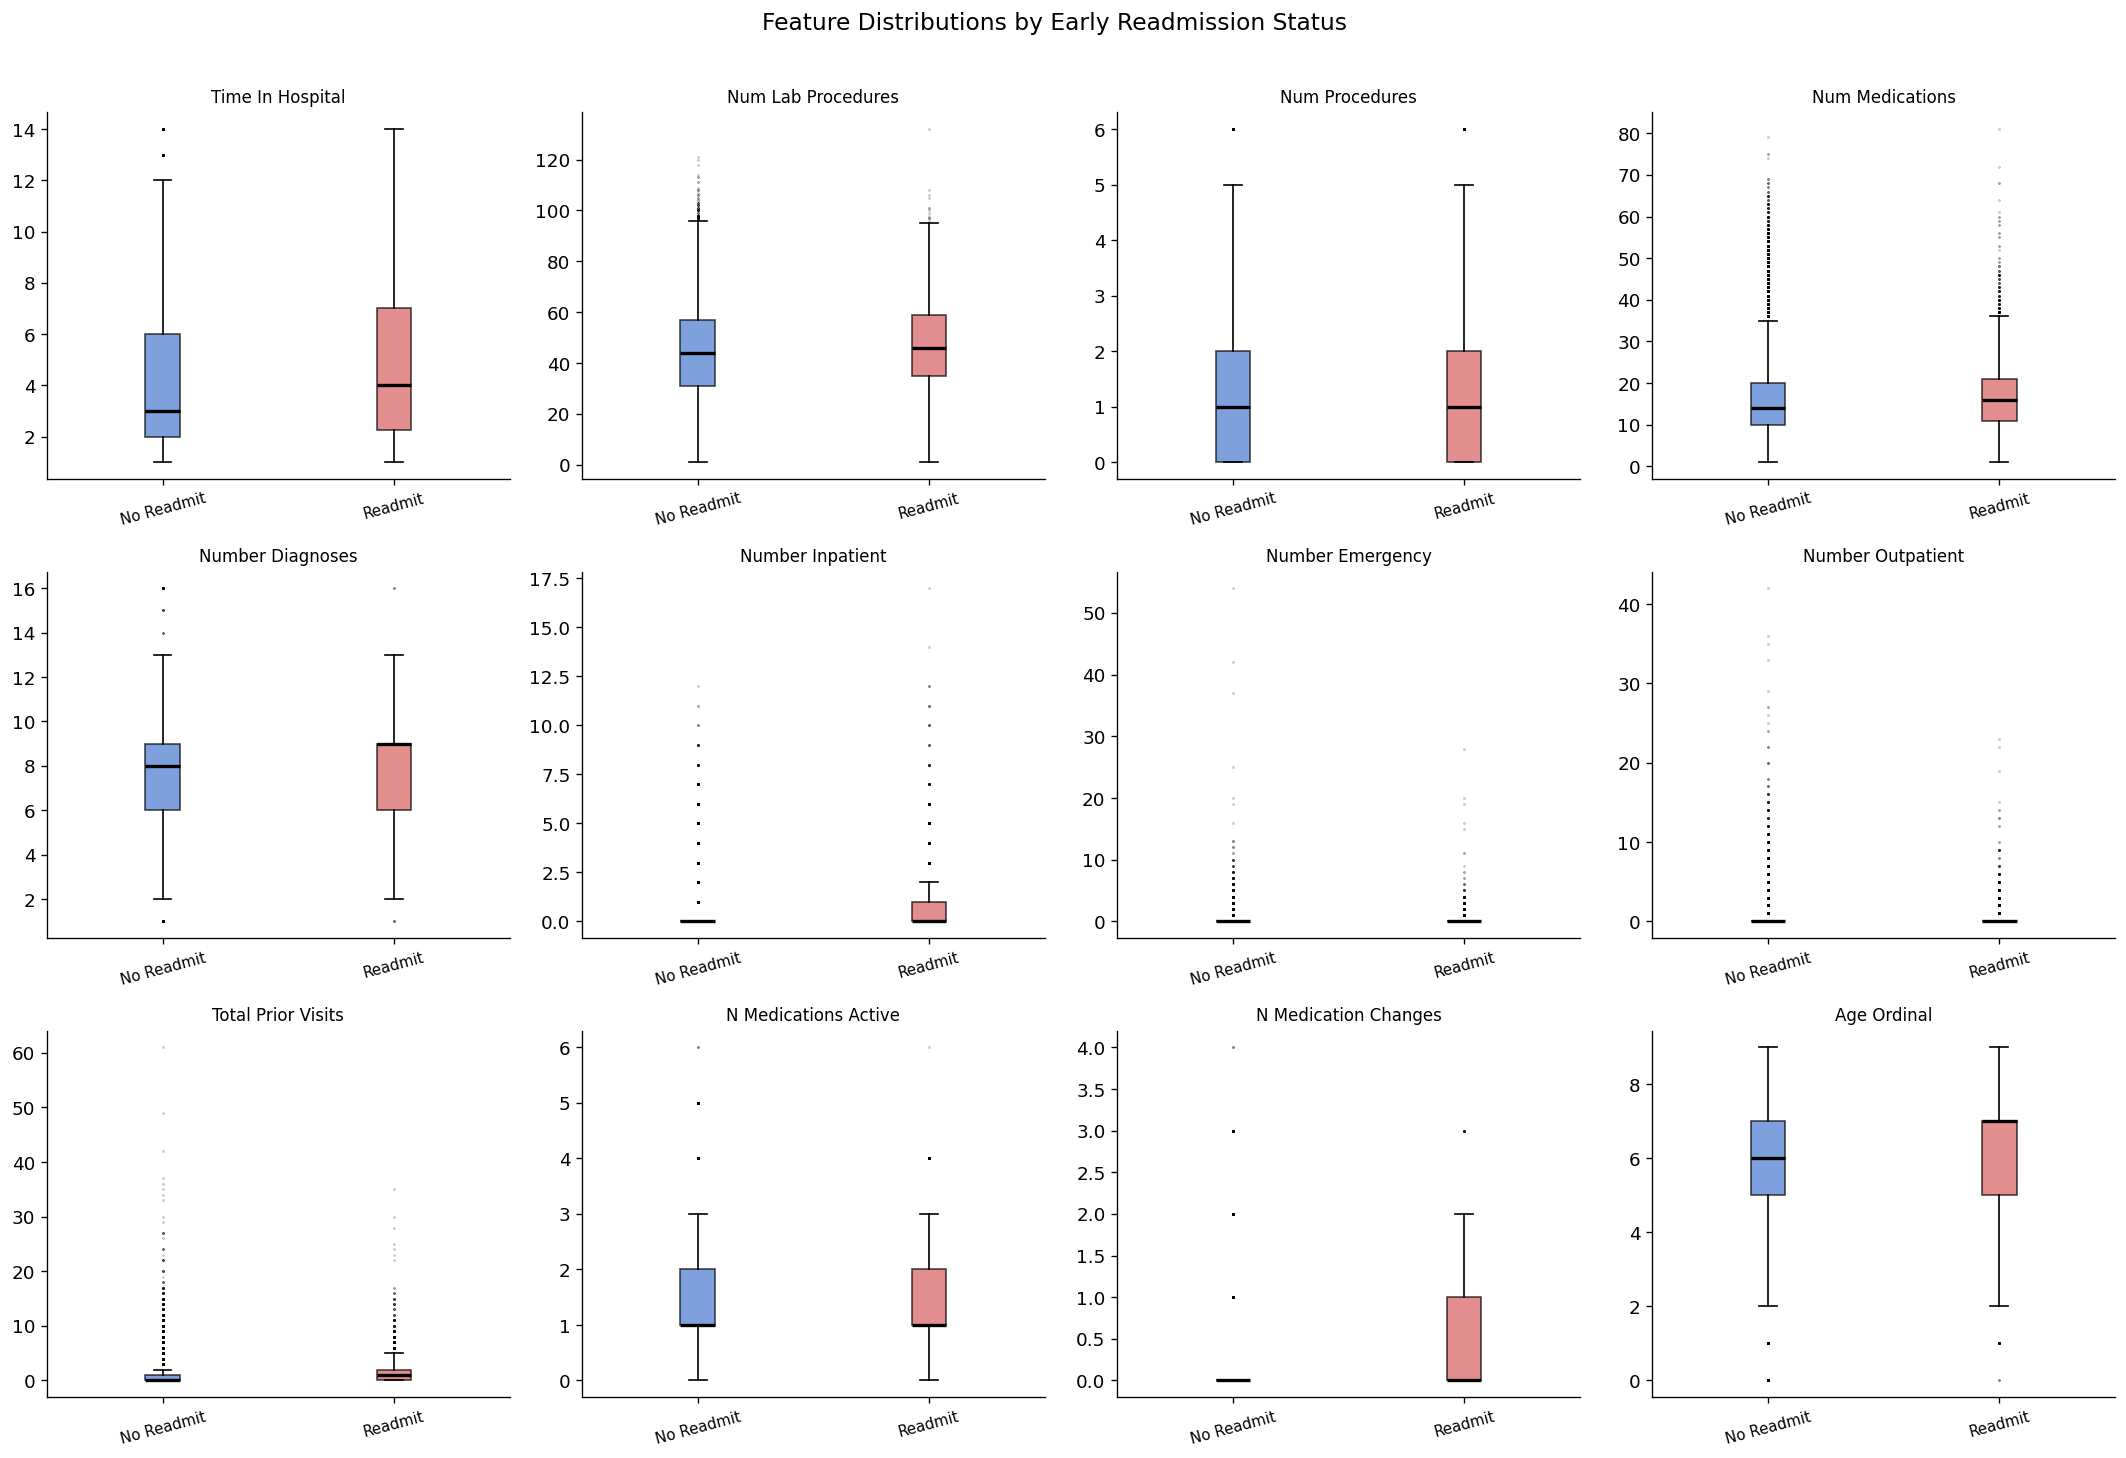

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(clinical_num[:12]):
    ax = axes[i]
    g0 = no_readmit[col].values
    g1 = readmit[col].values
    
    bp = ax.boxplot([g0, g1], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker=".", markersize=1, alpha=0.3))
    bp["boxes"][0].set_facecolor(COLORS["no_readmit"])
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor(COLORS["readmit"])
    bp["boxes"][1].set_alpha(0.7)
    
    ax.set_xticklabels(["No Readmit", "Readmit"], rotation=15, fontsize=9)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)

for j in range(len(clinical_num), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Early Readmission Status", fontsize=14, y=1.01)
plt.tight_layout()
save_figure(fig, "05_boxplots_by_target.png", FIGURES_DIR)
plt.show()

## Categorical feature vs target (readmission rates)

I computed the readmission rate within each category and test for independence using the chi-squared test.

In [ ]:
cat_cols = [c for c in ["diag_1_cat", "race", "admission_type_id",
                         "primary_diag_is_diabetes", "A1C_tested",
                         "glucose_tested", "on_diabetes_med", "med_changed",
                         "had_prior_inpatient"] if c in df.columns]

print("=== Categorical Features: Readmission Rate & Chi-Squared Test ===\n")
chi2_rows = []

for col in cat_cols:
    # Contingency table
    ct = pd.crosstab(df[col], df[TARGET_COL])
    if ct.shape[1] < 2:
        continue
    
    chi2, pval, dof, _ = stats.chi2_contingency(ct)
    
    # Overall readmission rate per category
    rates = (df.groupby(col)[TARGET_COL].mean() * 100).round(1)
    
    chi2_rows.append({
        "Feature": col,
        "N_categories": df[col].nunique(),
        "Chi2_stat": round(chi2, 2),
        "p_value": round(pval, 6),
        "Significant": "Yes" if pval < 0.05 else "No"
    })
    
    print(f"--- {col} ---")
    print(f"  Chi2={chi2:.2f}, p={pval:.6f}, dof={dof}")
    print(f"  Readmission rates per category:")
    print(rates.to_string(dtype=False))
    print()

chi2_df = pd.DataFrame(chi2_rows).set_index("Feature")
save_table(chi2_df, "05_categorical_chi2_tests.csv", TABLES_DIR)

=== Categorical Features: Readmission Rate & Chi-Squared Test ===

--- diag_1_cat ---
  Chi2=88.50, p=0.000000, dof=9
  Readmission rates per category:
diag_1_cat
Circulatory          8.0
Diabetes             4.5
Digestive            6.4
Genitourinary        7.3
Injury               8.9
Musculoskeletal      6.6
Neoplasm             7.5
Other                7.3
Other / External    11.9
Respiratory          6.3

--- race ---
  Chi2=29.54, p=0.000006, dof=4
  Readmission rates per category:
race
AfricanAmerican    6.5
Asian              6.3
Caucasian          7.8
Hispanic           6.5
Other              6.0

--- admission_type_id ---
  Chi2=46.80, p=0.000000, dof=7
  Readmission rates per category:
admission_type_id
1     7.6
2     7.1
3     6.8
4    11.1
5     6.3
6     9.5
7     0.0
8     7.5

--- primary_diag_is_diabetes ---
  Chi2=2.08, p=0.149647, dof=1
  Readmission rates per category:
primary_diag_is_diabetes
0    7.4
1    4.5

--- A1C_tested ---
  Chi2=18.22, p=0.000020, dof=1
  

'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\reports\\tables\\05_categorical_chi2_tests.csv'

## Readmission rate by age group

Age is now encoded as ordinal 0–9. I looked at the readmission rate per age group.

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\05_readmission_by_age.png


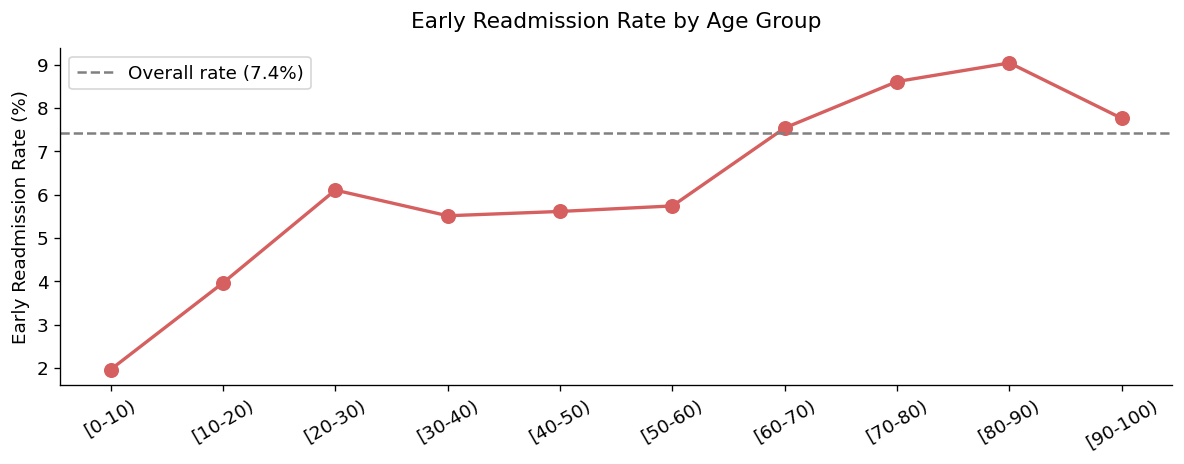

In [ ]:
age_readmit = df.groupby("age_ordinal")[TARGET_COL].mean() * 100
age_labels = {v: k for k, v in AGE_ORDER.items()}

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(age_readmit.index, age_readmit.values, 
        "o-", color=COLORS["readmit"], linewidth=2, markersize=8)
ax.set_xticks(sorted(AGE_ORDER.values()))
ax.set_xticklabels([age_labels[i] for i in sorted(AGE_ORDER.values())], rotation=30)
ax.set_ylabel("Early Readmission Rate (%)")
ax.set_title("Early Readmission Rate by Age Group", pad=12)
ax.axhline(df[TARGET_COL].mean()*100, color="gray", linestyle="--",
           label=f"Overall rate ({df[TARGET_COL].mean()*100:.1f}%)")
ax.legend()
plt.tight_layout()
save_figure(fig, "05_readmission_by_age.png", FIGURES_DIR)
plt.show()

## Correlation with target

In [7]:
# Point-biserial correlation between each numeric feature and the binary target.
# This is equivalent to Pearson correlation when one variable is binary.

numeric_for_corr = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in [TARGET_COL, PATIENT_ID_COL]]

corr_target = df[numeric_for_corr + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr_target = corr_target.sort_values(key=abs, ascending=False)

print("=== Feature Correlation with Target ===")
print(corr_target.round(4).to_string())
print()
print("Top 5 positively correlated:")
print(corr_target.nlargest(5).round(4).to_string())
print()
print("Top 5 negatively correlated:")
print(corr_target.nsmallest(5).round(4).to_string())

save_table(corr_target.to_frame("correlation"), "05_target_correlations.csv", TABLES_DIR)

=== Feature Correlation with Target ===
number_inpatient            0.1487
had_prior_inpatient         0.1202
total_prior_visits          0.1010
discharge_disposition_id    0.0576
number_diagnoses            0.0549
time_in_hospital            0.0530
age_ordinal                 0.0477
num_medications             0.0397
num_lab_procedures          0.0394
number_emergency            0.0388
insulin                     0.0300
n_medication_changes        0.0276
on_diabetes_med             0.0256
number_outpatient           0.0205
metformin                  -0.0171
A1C_tested                 -0.0162
A1Cresult_encoded          -0.0154
med_changed                 0.0154
repaglinide                 0.0141
glipizide                   0.0138
n_medication_increases      0.0113
admission_source_id         0.0096
glucose_tested              0.0094
n_medications_active        0.0086
max_glu_serum_encoded       0.0084
primary_diag_is_diabetes   -0.0060
chlorpropamide             -0.0054
glyburide      

'c:\\Users\\Peter\\Documents\\EXTRA-CURRICULA\\Internship\\Decodelab\\diabetes_readmission\\reports\\tables\\05_target_correlations.csv'

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\05_target_correlations.png


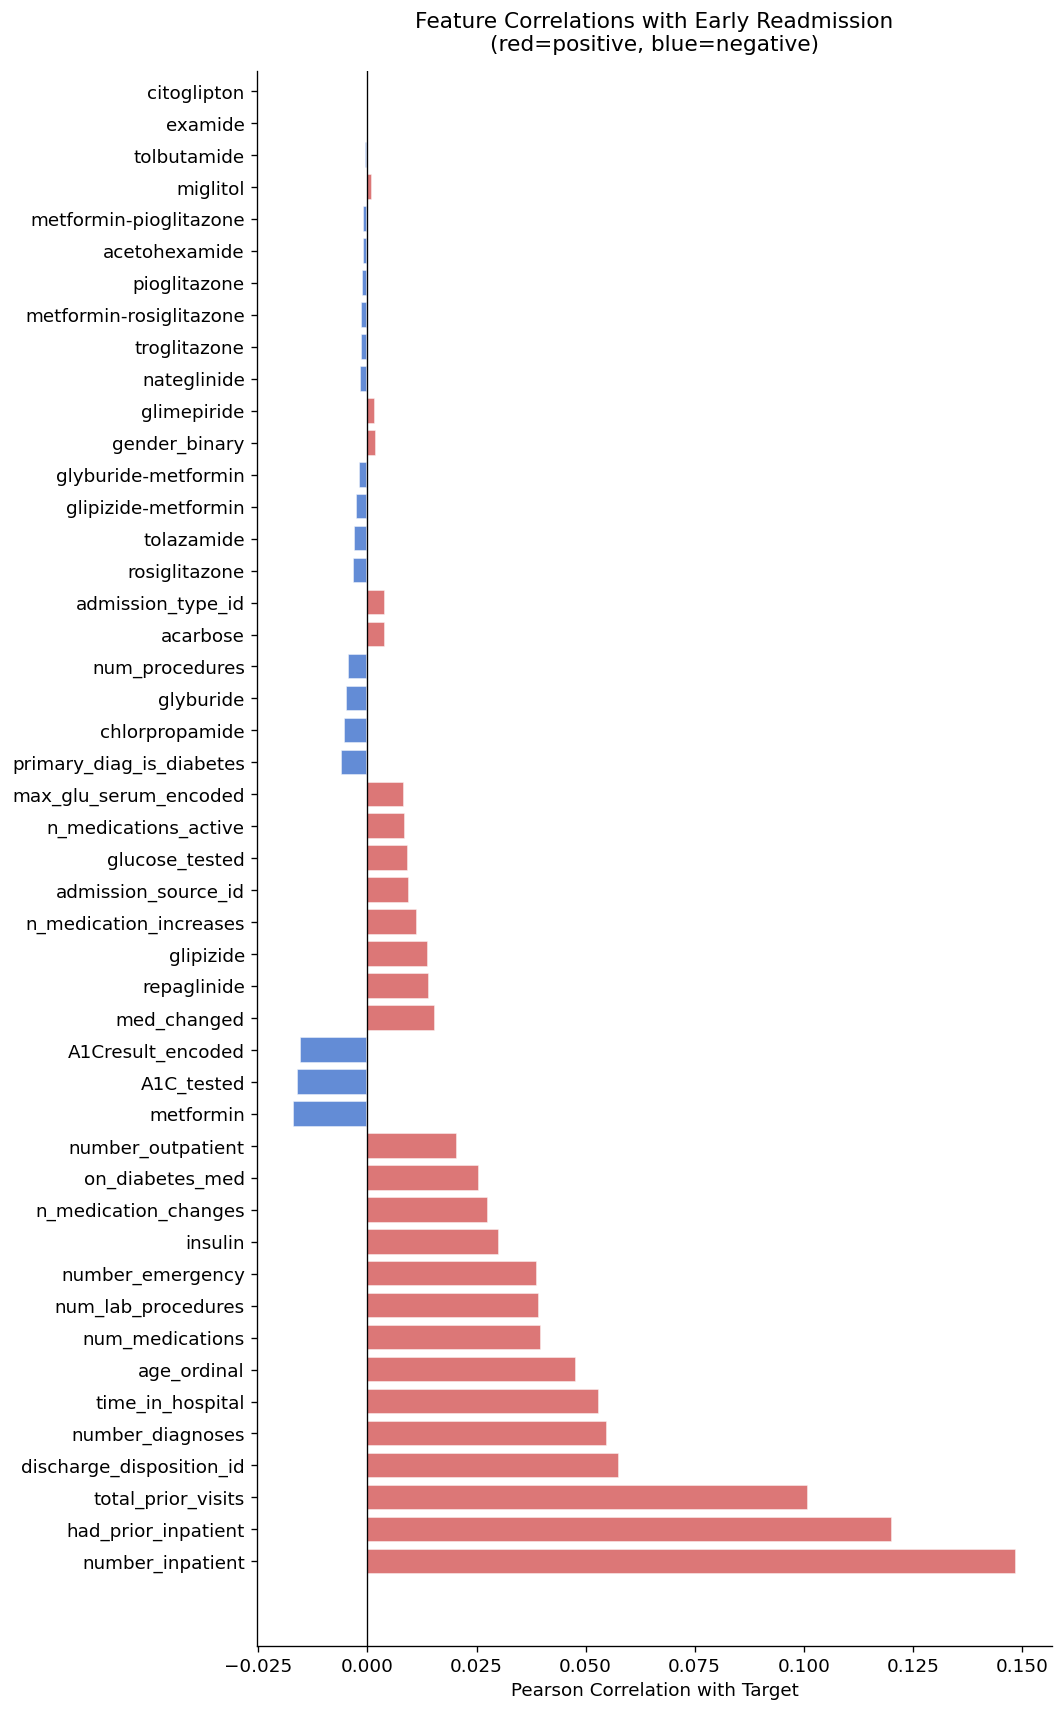

In [8]:
# Horizontal bar chart of correlations
fig, ax = plt.subplots(figsize=(9, max(6, len(corr_target)*0.3)))
colors_bar = [COLORS["readmit"] if c > 0 else COLORS["no_readmit"]
              for c in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors_bar, alpha=0.85, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target")
ax.set_title("Feature Correlations with Early Readmission\n(red=positive, blue=negative)", pad=12)
plt.tight_layout()
save_figure(fig, "05_target_correlations.png", FIGURES_DIR)
plt.show()

## Correlation matrix heatmap

I checked for highly correlated feature PAIRS.

  Figure saved → c:\Users\Peter\Documents\EXTRA-CURRICULA\Internship\Decodelab\diabetes_readmission\reports\figures\05_correlation_heatmap.png


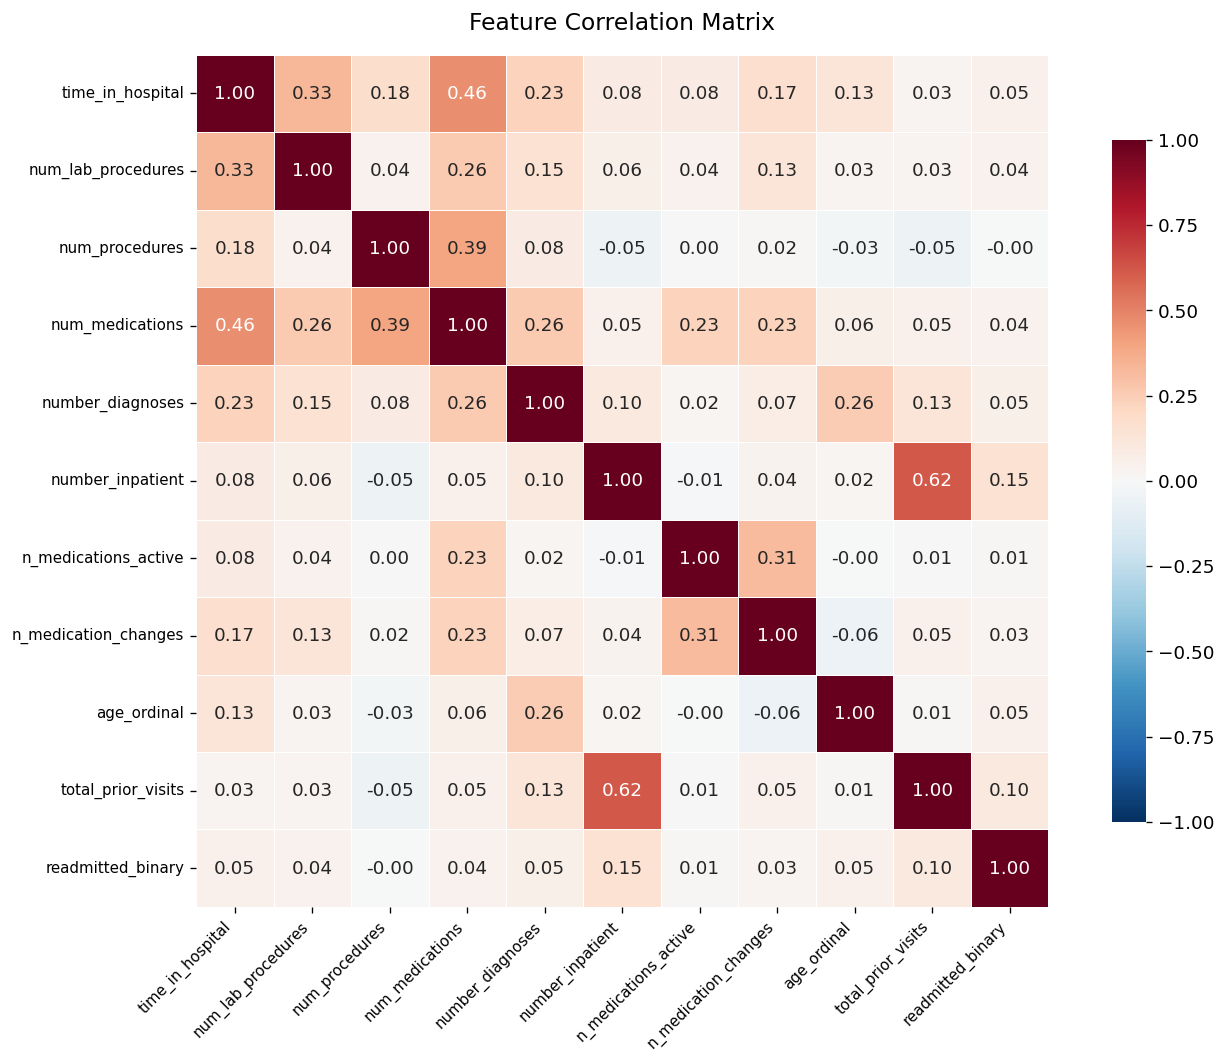

In [10]:
# Very high correlation (|r| > 0.85) between two features means they are redundant.

# Use only a subset of informative features for readability
heatmap_cols = ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_diagnoses", "number_inpatient",
                "n_medications_active", "n_medication_changes", "age_ordinal",
                "total_prior_visits", TARGET_COL]
heatmap_cols = [c for c in heatmap_cols if c in df.columns]

corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8},
            xticklabels=True, yticklabels=True)
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
save_figure(fig, "05_correlation_heatmap.png", FIGURES_DIR)
plt.show()